In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [66]:
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 150,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.2,
})

COR_AZUL  = '#2E75B6'
COR_VERM  = '#E24B4A'
COR_CINZA = '#888888'
COR_VERDE = '#1D9E75'
COR_AMBER = '#BA7517'
P2 = [COR_AZUL, COR_VERM]

In [67]:
df = pd.read_csv('dataset_limpo.csv')

In [69]:
#deixar na ordem lógica correta, para a visualização assertivas dos dados
ordem_idade = ['Jovem (18-30)', 'Adulto (31-45)', 'Maduro (46-60)', 'Sênior (61+)']
df['faixa_etaria'] = pd.Categorical(df['faixa_etaria'], categories=ordem_idade, ordered=True)

ordem_renda = ['Baixa (<2k)', 'Média (2k-5k)', 'Alta (5k-10k)', 'Muito Alta (>10k)']
df['faixa_renda'] = pd.Categorical(df['faixa_renda'], categories=ordem_renda, ordered=True)

ordem_atrasos = ['Sem atrasos', 'Poucos atrasos', 'Muitos atrasos']
df['perfil_historico'] = pd.Categorical(df['perfil_historico'], categories=ordem_atrasos, ordered=True)

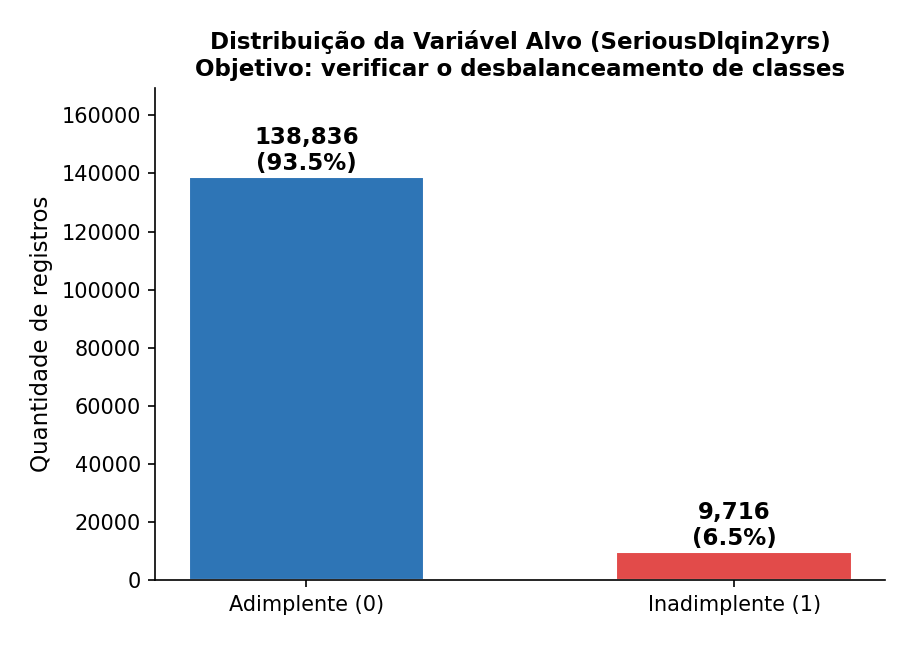

In [71]:
# GRAFICO 1 — Variavel alvo
fig, ax = plt.subplots(figsize=(6,4.2))
cnt = df['SeriousDlqin2yrs'].value_counts().sort_index()
pct = df['SeriousDlqin2yrs'].value_counts(normalize=True).sort_index()*100
bars = ax.bar(['Adimplente (0)','Inadimplente (1)'], cnt.values, color=P2, edgecolor='white', width=0.55)
for bar,v,p in zip(bars, cnt.values, pct.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+600, f'{v:,}\n({p:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylim(0, max(cnt.values)*1.22)
ax.set_ylabel('Quantidade de registros', fontsize=11)
ax.set_title('Distribuição da Variável Alvo (SeriousDlqin2yrs)\nObjetivo: verificar o desbalanceamento de classes', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.savefig('eda_01_variavel_alvo.png');
plt.show()
plt.close()


C:\Users\pedro\AppData\Local\Temp\ipykernel_16420\780013959.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  taxa = df.groupby('faixa_etaria')['SeriousDlqin2yrs'].mean()*100


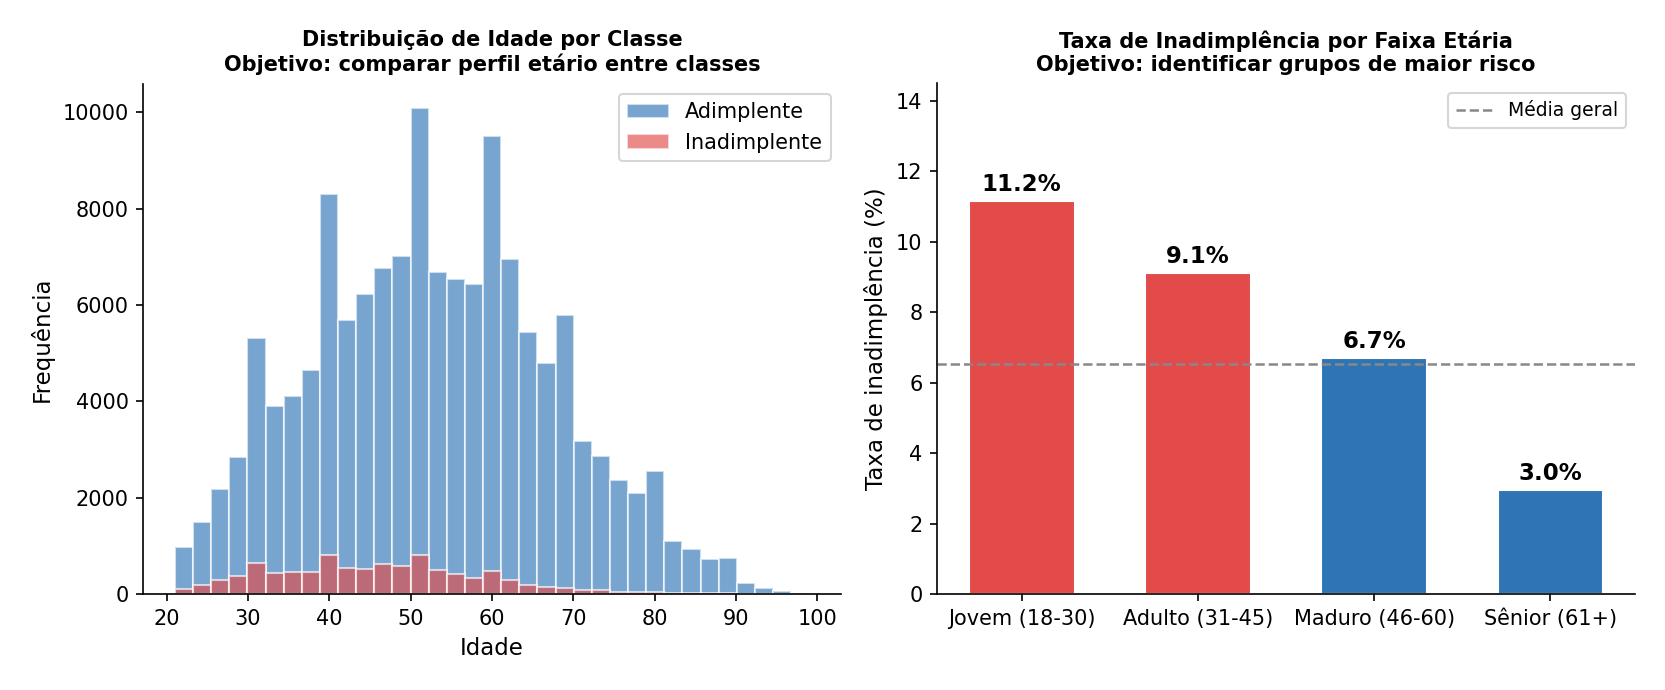

In [72]:
# GRAFICO 2 — Idade
fig, axes = plt.subplots(1,2,figsize=(11,4.5))
ax=axes[0]
for lbl,cor in [('Adimplente',COR_AZUL),('Inadimplente',COR_VERM)]:
    v=0 if lbl=='Adimplente' else 1
    ax.hist(df[df['SeriousDlqin2yrs']==v]['age'], bins=35, color=cor, alpha=0.65, label=lbl, edgecolor='white')
ax.set_xlabel('Idade',fontsize=11); ax.set_ylabel('Frequência',fontsize=11)
ax.set_title('Distribuição de Idade por Classe\nObjetivo: comparar perfil etário entre classes', fontsize=10, fontweight='bold')
ax.legend(fontsize=10)
ax=axes[1]
taxa = df.groupby('faixa_etaria')['SeriousDlqin2yrs'].mean()*100
cores=[COR_AZUL if v<7 else COR_AMBER if v<9 else COR_VERM for v in taxa.values]
brs=ax.bar(taxa.index, taxa.values, color=cores, edgecolor='white', width=0.6)
for bar,val in zip(brs, taxa.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.15, f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('Taxa de inadimplência (%)',fontsize=11)
ax.set_title('Taxa de Inadimplência por Faixa Etária\nObjetivo: identificar grupos de maior risco', fontsize=10, fontweight='bold')
ax.set_ylim(0, taxa.max()*1.3)
ax.axhline(df['SeriousDlqin2yrs'].mean()*100, color=COR_CINZA, linestyle='--', linewidth=1.2, label='Média geral')
ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig('eda_02_idade.png');
plt.show()
plt.close()

C:\Users\pedro\AppData\Local\Temp\ipykernel_16420\3138994155.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tr = df.groupby('faixa_renda')['SeriousDlqin2yrs'].mean()*100


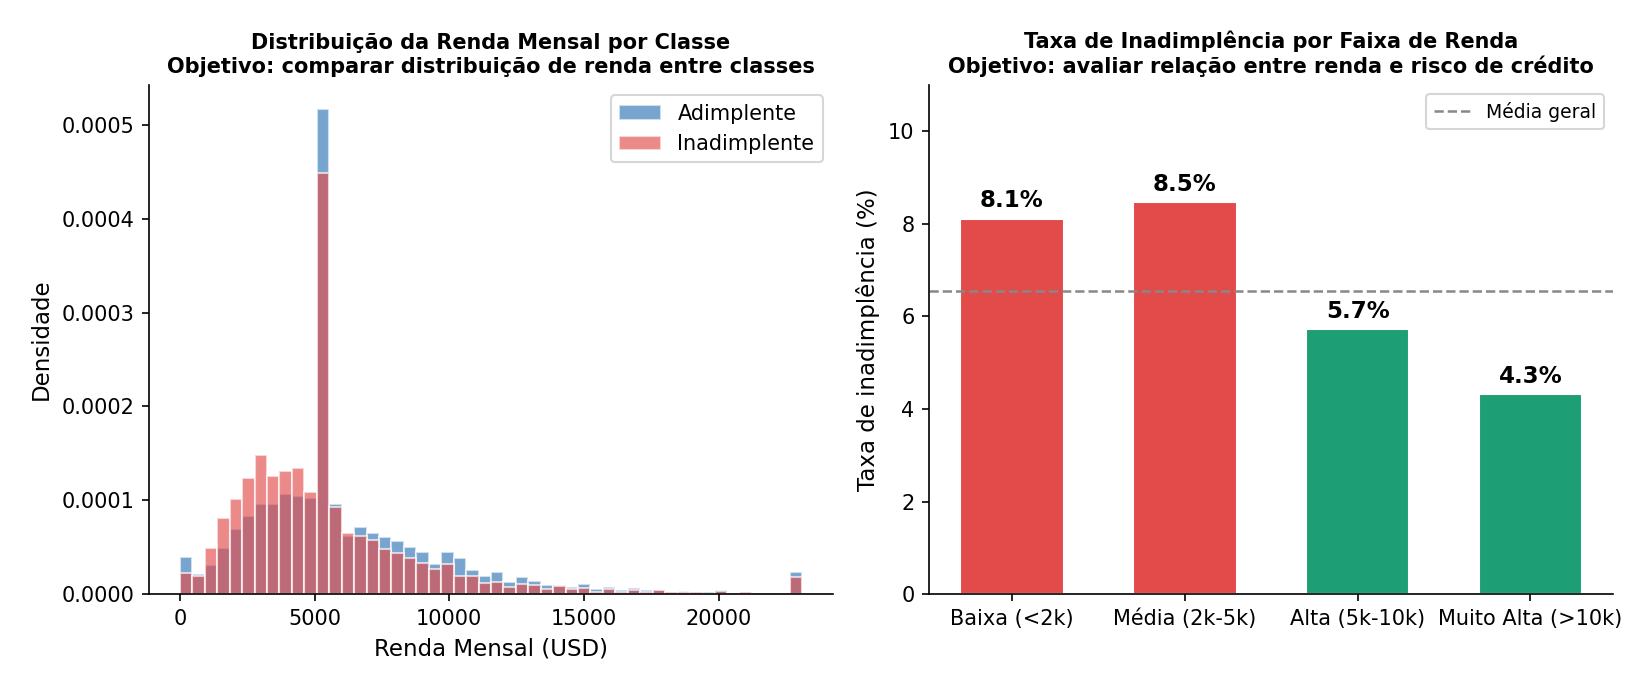

In [73]:
fig, axes = plt.subplots(1,2,figsize=(11,4.5))
ax=axes[0]
for lbl,cor in [('Adimplente',COR_AZUL),('Inadimplente',COR_VERM)]:
    v=0 if lbl=='Adimplente' else 1
    ax.hist(df[df['SeriousDlqin2yrs']==v]['MonthlyIncome'], bins=50, color=cor, alpha=0.65, label=lbl, edgecolor='white', density=True)
ax.set_xlabel('Renda Mensal (USD)',fontsize=11); ax.set_ylabel('Densidade',fontsize=11)
ax.set_title('Distribuição da Renda Mensal por Classe\nObjetivo: comparar distribuição de renda entre classes', fontsize=10, fontweight='bold')
ax.legend(fontsize=10)
ax=axes[1]
tr = df.groupby('faixa_renda')['SeriousDlqin2yrs'].mean()*100
cr = [COR_VERM if v>8 else COR_AMBER if v>6 else COR_VERDE for v in tr.values]
brs2=ax.bar(tr.index, tr.values, color=cr, edgecolor='white', width=0.6)
for bar,val in zip(brs2, tr.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.15, f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('Taxa de inadimplência (%)',fontsize=11)
ax.set_title('Taxa de Inadimplência por Faixa de Renda\nObjetivo: avaliar relação entre renda e risco de crédito', fontsize=10, fontweight='bold')
ax.set_ylim(0, tr.max()*1.3)
ax.axhline(df['SeriousDlqin2yrs'].mean()*100, color=COR_CINZA, linestyle='--', linewidth=1.2, label='Média geral')
ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig('eda_03_renda.png'); 
plt.show()
plt.close()

C:\Users\pedro\AppData\Local\Temp\ipykernel_16420\2975267374.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tp = df.groupby('perfil_historico')['SeriousDlqin2yrs'].mean().reindex(ordem)*100
C:\Users\pedro\AppData\Local\Temp\ipykernel_16420\2975267374.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prop = df.groupby('perfil_historico')['SeriousDlqin2yrs'].value_counts(normalize=True).unstack().reindex(ordem)


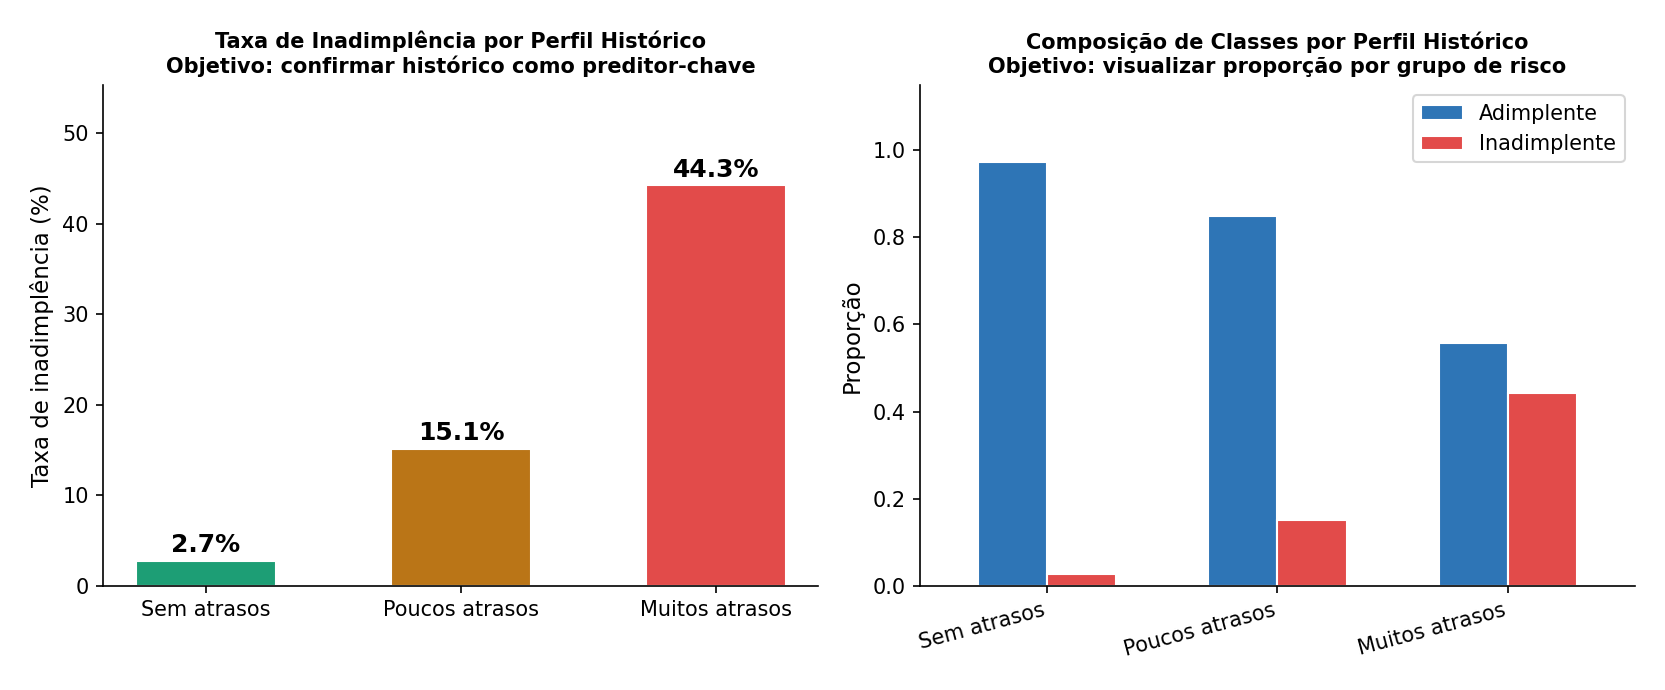

In [74]:
# GRAFICO 4 — Historico atrasos
fig, axes = plt.subplots(1,2,figsize=(11,4.5))
ax=axes[0]
ordem=['Sem atrasos','Poucos atrasos','Muitos atrasos']
tp = df.groupby('perfil_historico')['SeriousDlqin2yrs'].mean().reindex(ordem)*100
cp=[COR_VERDE,COR_AMBER,COR_VERM]
brs3=ax.bar(tp.index, tp.values, color=cp, edgecolor='white', width=0.55)
for bar,val in zip(brs3, tp.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4, f'{val:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_ylabel('Taxa de inadimplência (%)',fontsize=11)
ax.set_title('Taxa de Inadimplência por Perfil Histórico\nObjetivo: confirmar histórico como preditor-chave', fontsize=10, fontweight='bold')
ax.set_ylim(0, tp.max()*1.25)
ax=axes[1]
prop = df.groupby('perfil_historico')['SeriousDlqin2yrs'].value_counts(normalize=True).unstack().reindex(ordem)
prop.columns=['Adimplente','Inadimplente']
prop.plot(kind='bar', ax=ax, color=P2, edgecolor='white', width=0.6)
ax.set_ylabel('Proporção',fontsize=11); ax.set_xlabel('')
ax.set_xticklabels(ordem, rotation=15, ha='right', fontsize=10)
ax.set_title('Composição de Classes por Perfil Histórico\nObjetivo: visualizar proporção por grupo de risco', fontsize=10, fontweight='bold')
ax.legend(fontsize=10); ax.set_ylim(0,1.15)
plt.tight_layout(); plt.savefig('eda_04_historico_atrasos.png')
plt.show()
plt.close()

C:\Users\pedro\AppData\Local\Temp\ipykernel_16420\3557995603.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tu=df.groupby('faixa_util')['SeriousDlqin2yrs'].mean()*100


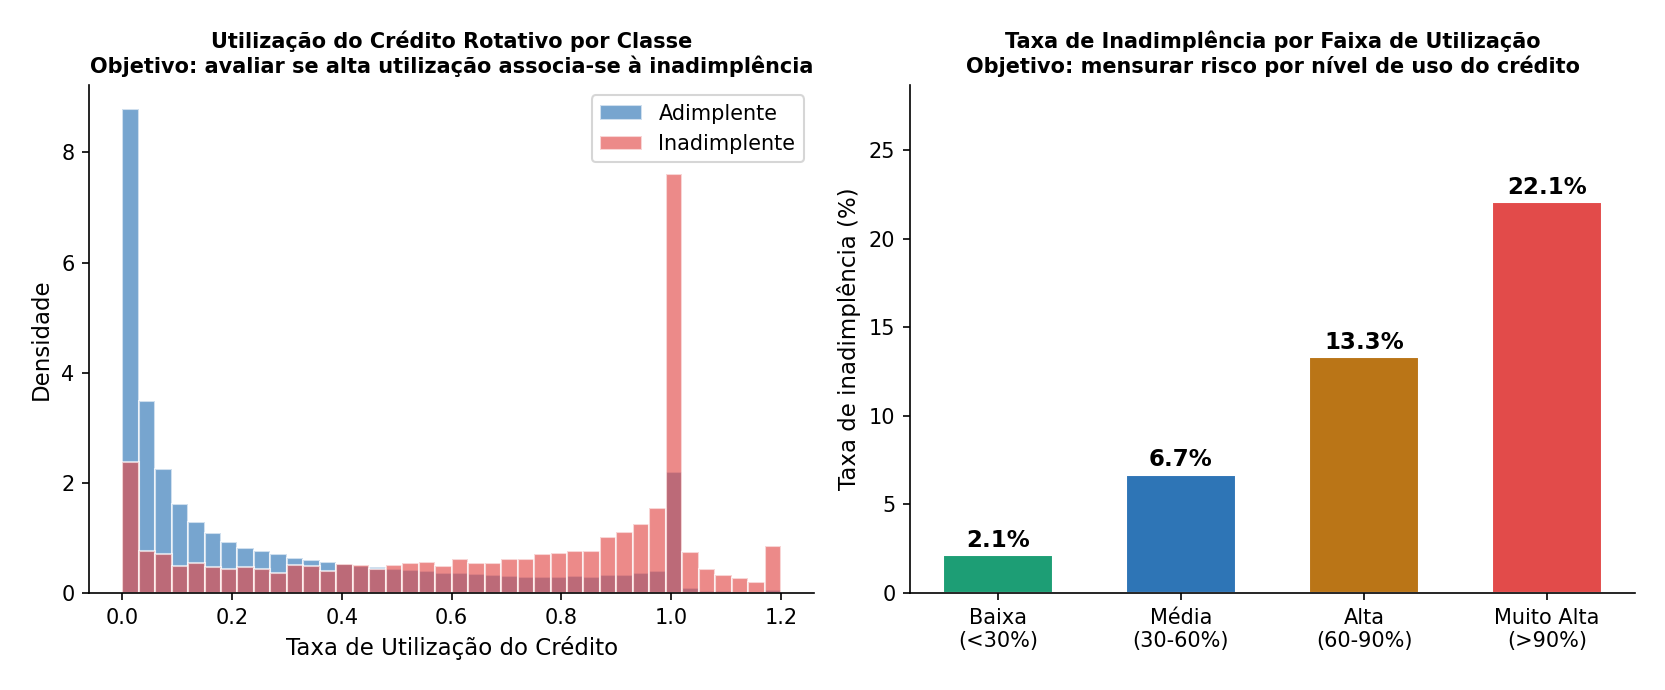

In [78]:
# GRAFICO 5 — Utilizacao credito
fig, axes = plt.subplots(1,2,figsize=(11,4.5))
ax=axes[0]
for lbl,cor in [('Adimplente',COR_AZUL),('Inadimplente',COR_VERM)]:
    v=0 if lbl=='Adimplente' else 1
    ax.hist(df[df['SeriousDlqin2yrs']==v]['RevolvingUtilizationOfUnsecuredLines'].clip(0,1.2), bins=40, color=cor, alpha=0.65, label=lbl, edgecolor='white', density=True)
ax.set_xlabel('Taxa de Utilização do Crédito',fontsize=11); ax.set_ylabel('Densidade',fontsize=11)
ax.set_title('Utilização do Crédito Rotativo por Classe\nObjetivo: avaliar se alta utilização associa-se à inadimplência', fontsize=10, fontweight='bold')
ax.legend(fontsize=10)
ax=axes[1]
df['faixa_util']=pd.cut(df['RevolvingUtilizationOfUnsecuredLines'], bins=[0,0.3,0.6,0.9,2.0], labels=['Baixa\n(<30%)','Média\n(30-60%)','Alta\n(60-90%)','Muito Alta\n(>90%)'])
tu=df.groupby('faixa_util')['SeriousDlqin2yrs'].mean()*100
cu=[COR_VERDE,COR_AZUL,COR_AMBER,COR_VERM]
brs4=ax.bar(tu.index, tu.values, color=cu, edgecolor='white', width=0.6)
for bar,val in zip(brs4, tu.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2, f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('Taxa de inadimplência (%)',fontsize=11)
ax.set_title('Taxa de Inadimplência por Faixa de Utilização\nObjetivo: mensurar risco por nível de uso do crédito', fontsize=10, fontweight='bold')
ax.set_ylim(0, tu.max()*1.3)
plt.tight_layout(); plt.savefig('eda_05_utilizacao_credito.png');
plt.show()
plt.close()

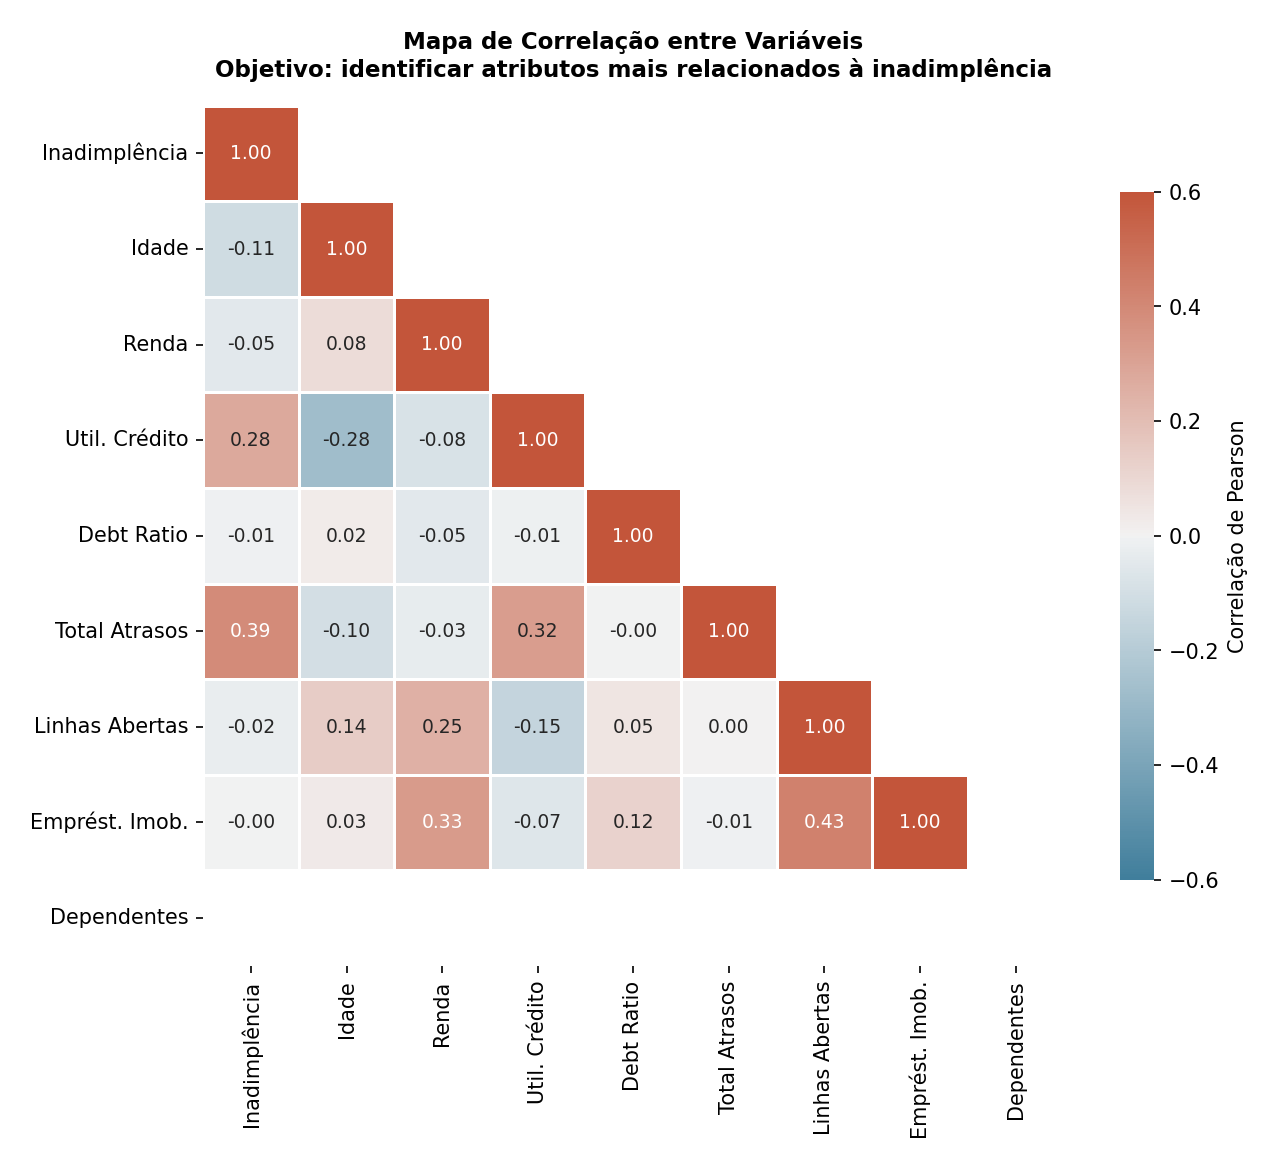

In [77]:
# GRAFICO 6 — Correlacao
cols_c=['SeriousDlqin2yrs','age','MonthlyIncome','RevolvingUtilizationOfUnsecuredLines','DebtRatio','total_atrasos','NumberOfOpenCreditLinesAndLoans','NumberRealEstateLoansOrLines','NumberOfDependents']
labs_c=['Inadimplência','Idade','Renda','Util. Crédito','Debt Ratio','Total Atrasos','Linhas Abertas','Emprést. Imob.','Dependentes']
corr = df[cols_c].corr()
corr.index=labs_c; corr.columns=labs_c
fig, ax = plt.subplots(figsize=(9,7.5))
mask=np.triu(np.ones_like(corr, dtype=bool), k=1)
cmap=sns.diverging_palette(230,20,as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=0.6, vmin=-0.6, center=0, annot=True, fmt='.2f', annot_kws={'size':9}, square=True, linewidths=0.5, ax=ax, cbar_kws={'shrink':0.8,'label':'Correlação de Pearson'})
ax.set_title('Mapa de Correlação entre Variáveis\nObjetivo: identificar atributos mais relacionados à inadimplência', fontsize=11, fontweight='bold', pad=14)
plt.tight_layout(); plt.savefig('eda_06_correlacao.png'); 
plt.show()
plt.close()

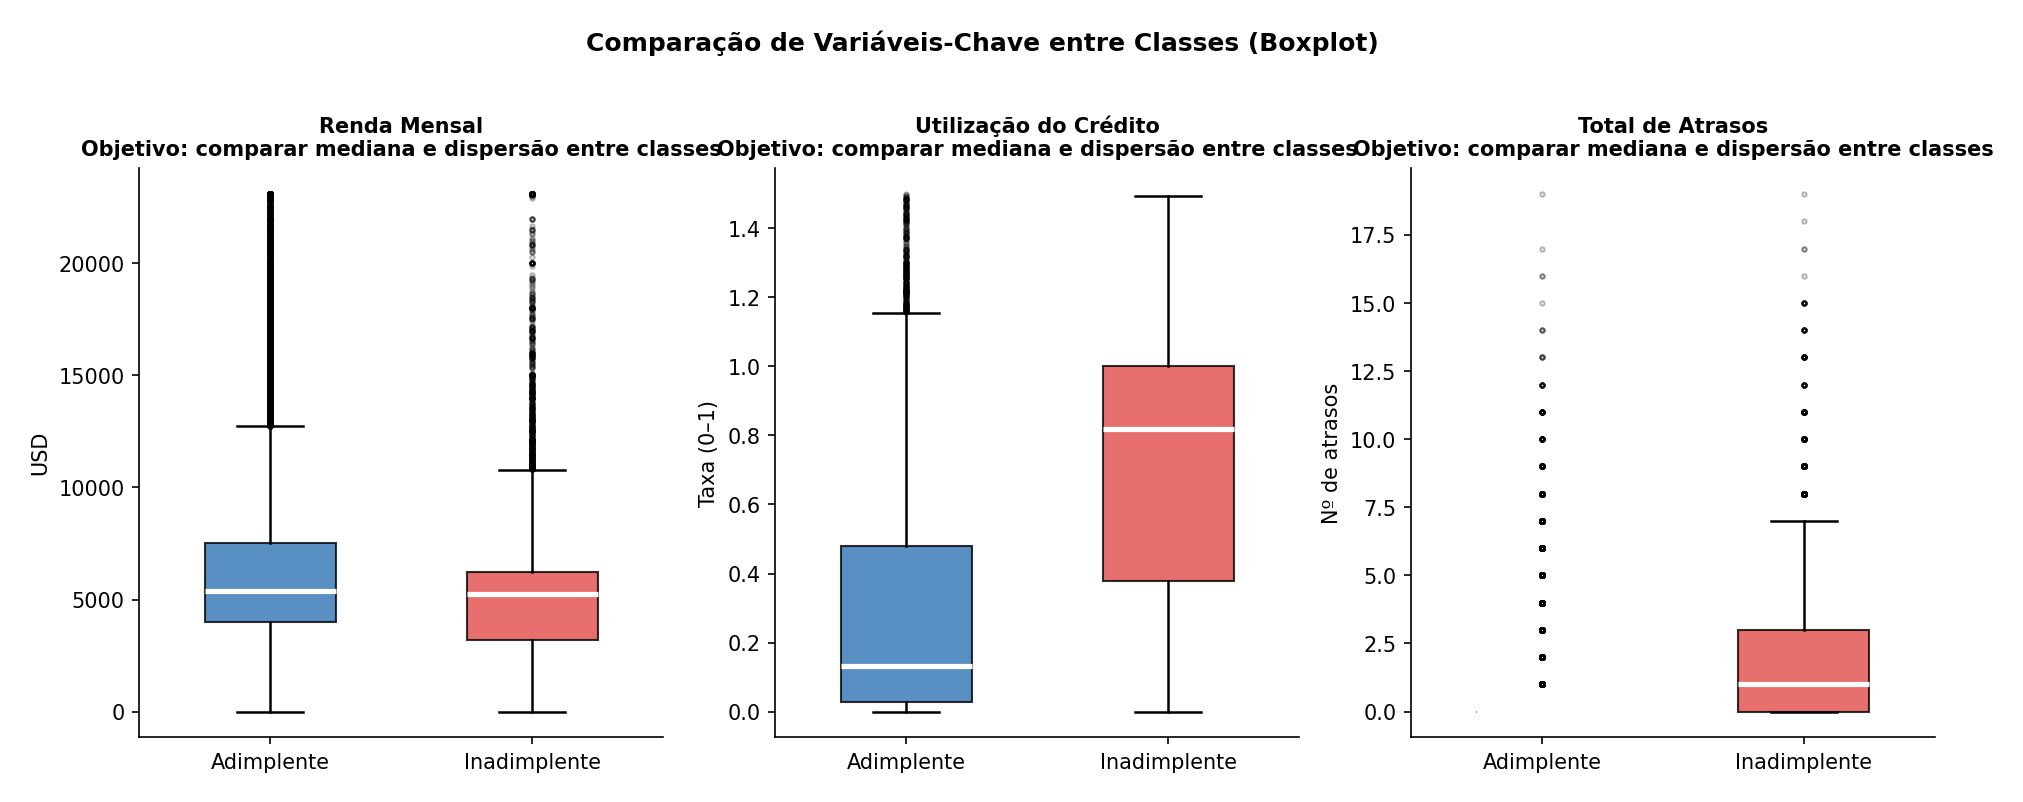

In [82]:
 #GRAFICO 7 — Boxplots
fig, axes = plt.subplots(1,3,figsize=(13,5))
vrs=[('MonthlyIncome','Renda Mensal','USD'),('RevolvingUtilizationOfUnsecuredLines','Utilização do Crédito','Taxa (0–1)'),('total_atrasos','Total de Atrasos','Nº de atrasos')]
for ax,(var,tit,ylab) in zip(axes, vrs):
    dados=[df[df['SeriousDlqin2yrs']==0][var], df[df['SeriousDlqin2yrs']==1][var]]
    bp=ax.boxplot(dados, patch_artist=True, widths=0.5, medianprops=dict(color='white',linewidth=2.5), whiskerprops=dict(linewidth=1.2), capprops=dict(linewidth=1.2), flierprops=dict(marker='o',markersize=2,alpha=0.3))
    for patch,cor in zip(bp['boxes'], P2):
        patch.set_facecolor(cor); patch.set_alpha(0.8)
    ax.set_xticks([1,2]); ax.set_xticklabels(['Adimplente','Inadimplente'],fontsize=10)
    ax.set_ylabel(ylab,fontsize=10)
    ax.set_title(f'{tit}\nObjetivo: comparar mediana e dispersão entre classes', fontsize=10, fontweight='bold')
plt.suptitle('Comparação de Variáveis-Chave entre Classes (Boxplot)', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('eda_07_boxplots.png')
plt.show()
plt.close()

C:\Users\pedro\AppData\Local\Temp\ipykernel_16420\2823680375.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  to=df.groupby(pd.cut(df['NumberOfOpenCreditLinesAndLoans'], bins=[0,3,7,12,30], labels=['1-3','4-7','8-12','13+']))['SeriousDlqin2yrs'].mean()*100


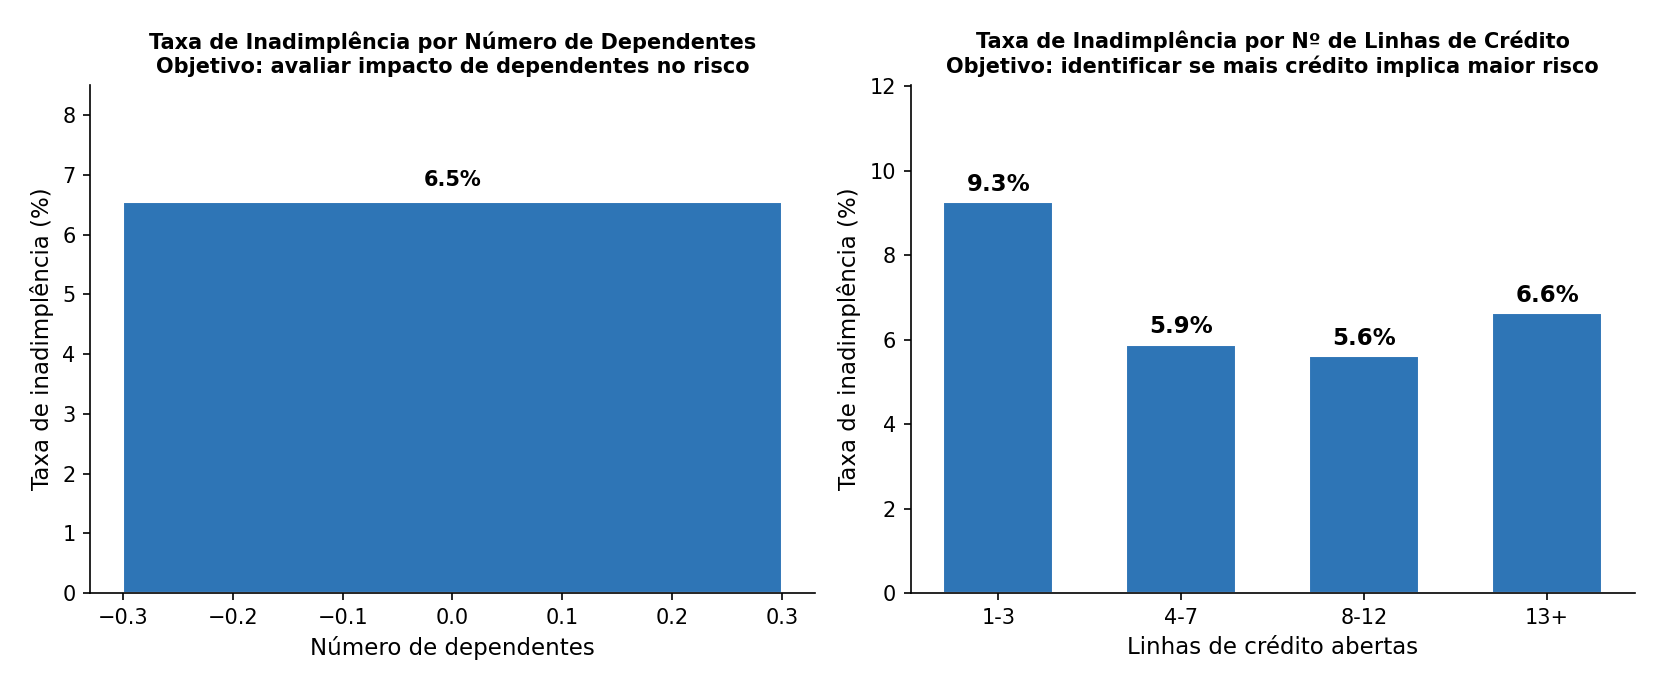

In [84]:
# GRAFICO 8 — Dependentes e linhas
fig, axes = plt.subplots(1,2,figsize=(11,4.5))
ax=axes[0]
td=df.groupby('NumberOfDependents')['SeriousDlqin2yrs'].mean().iloc[:6]*100
ax.bar(td.index, td.values, color=COR_AZUL, edgecolor='white', width=0.6)
for x,val in zip(td.index, td.values):
    ax.text(x, val+0.2, f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_xlabel('Número de dependentes',fontsize=11); ax.set_ylabel('Taxa de inadimplência (%)',fontsize=11)
ax.set_title('Taxa de Inadimplência por Número de Dependentes\nObjetivo: avaliar impacto de dependentes no risco', fontsize=10, fontweight='bold')
ax.set_ylim(0, td.max()*1.3)
ax=axes[1]
to=df.groupby(pd.cut(df['NumberOfOpenCreditLinesAndLoans'], bins=[0,3,7,12,30], labels=['1-3','4-7','8-12','13+']))['SeriousDlqin2yrs'].mean()*100
brs5=ax.bar(to.index, to.values, color=COR_AZUL, edgecolor='white', width=0.6)
for bar,val in zip(brs5, to.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.15, f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_xlabel('Linhas de crédito abertas',fontsize=11); ax.set_ylabel('Taxa de inadimplência (%)',fontsize=11)
ax.set_title('Taxa de Inadimplência por Nº de Linhas de Crédito\nObjetivo: identificar se mais crédito implica maior risco', fontsize=10, fontweight='bold')
ax.set_ylim(0, to.max()*1.3)
plt.tight_layout(); plt.savefig('eda_08_dependentes_linhas.png')
plt.show()
plt.close()